#### Use 'Python (llama_env)' kernel!

In [3]:
import torch
print(torch.__version__)
print(torch.randn(2, 2))

2.10.0+cpu
tensor([[-0.7728,  0.8315],
        [ 0.7118,  0.1841]])


In [4]:
import os
import math
from google import genai
from google.genai.types import GenerateContentConfig
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import random

from google.genai import types
from google.genai.errors import APIError


import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from semantic_entropy_utils import (
    EntailmentDeberta,
    get_semantic_ids,
    cluster_assignment_entropy
)


C:\Users\marie\anaconda3\envs\llama_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MULTIPLE CHOICE QUESTIONS

In [4]:
dataset_name = 'college_biology'
splits = {
    'test': f'{dataset_name}/test-00000-of-00001.parquet',
    'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
    'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
}
base_url = "hf://datasets/cais/mmlu/"
df_full = pd.read_parquet(base_url + splits["test"])


In [6]:
df_full

,question,subject,choices,answer
0,Based on the characteristic population curves ...,college_biology,[maintain the population at a point correspond...,2
1,A frameshift mutation is created when,college_biology,"[telomeric sequences are removed from DNA, a c...",2
2,"To prevent desiccation and injury, the embryos...",college_biology,"[amnion, chorion, allantois, yolk sac]",0
3,Which of the following is a second messenger t...,college_biology,"[Prostaglandins, Inositol triphosphate, Cyclic...",1
4,Synthesis of an RNA/DNA hybrid from a single-s...,college_biology,[a DNA or RNA primer and reverse transcriptase...,0
...,...,...,...,...
139,Which of the following is a correct statement ...,college_biology,[The evaporation of water from leaf mesophyll ...,0
140,"In fungi, cell walls are reinforced by which o...",college_biology,"[Chitin, Silica, Lignin, Collagen fibers]",0
141,"In plants, proton pumps are involved in the pr...",college_biology,"[It is passive., It depends on DNA., It requir...",2
142,Which of the following characteristics is pred...,college_biology,[High niche divergence among co-occurring spec...,1


## The cluster_assignment_entropy function
Can be found in: semantic_uncertainty/semantic_uncertainty/uncertainty/uncertainty_measures
/semantic_entropy.py

In [5]:
# cluster assignment entropy means discrete entropy
def cluster_assignment_entropy(semantic_ids):
    """Estimate semantic uncertainty from how often different clusters get assigned.

    We estimate the categorical distribution over cluster assignments from the
    semantic ids. The uncertainty is then given by the entropy of that
    distribution. This estimate does not use token likelihoods, it relies soley
    on the cluster assignments. If probability mass is spread of between many
    clusters, entropy is larger. If probability mass is concentrated on a few
    clusters, entropy is small.

    Input:
        semantic_ids: List of semantic ids, e.g. [0, 1, 2, 1].
    Output:
        cluster_entropy: Entropy, e.g. (-p log p).sum() for p = [1/4, 2/4, 1/4].
    """

    n_generations = len(semantic_ids)
    counts = np.bincount(semantic_ids) # counts is list with counts per cluster_id
    probabilities = counts/n_generations # probabilities is list with probability of cluster_id
    assert np.isclose(probabilities.sum(), 1)
    #print(probabilities)
    entropy = - (probabilities * np.log(probabilities)).sum() # formula for shannon entropy
    return entropy

In [8]:
semantic_ids = [0, 1, 1, 1]
print(cluster_assignment_entropy(semantic_ids))

[0.25 0.75]
0.5623351446188083


### Testing out the entailment model

In [131]:
entailment_model = EntailmentDeberta()

p = "A dog is running in the park."
h1 = "An animal is outdoors."
h2 = "There is no dog."

# 0 is contradiction, 1 is neutral, 2 is implication
print(entailment_model.check_implication(p, h1))  # 2.0, because p implies h1
print(entailment_model.check_implication(h1, p))  # 1.0, because h1 does not imply p
print(entailment_model.check_implication(p, h2))  # 0.0 because p and h2 are a contradiction


2
1
0


In [132]:
answer1 = 'The amnion encases the embryo in a fluid-filled sac, protecting it from desiccation and injury.'
answer2 = 'The embryos of terrestrial vertebrates are encased within a fluid secreted by the amnion.'

print(entailment_model.check_implication(answer1, answer2))
print(entailment_model.check_implication(answer2, answer1))

1
1


### Calibration plot function using Discrete Entropy
TO DO:
- Understand entailment model ✅
- Run this function (if finished) and compare calibration plots ✅
- Start to work on open ended questions ✅


PIPELINE MULTIPLE CHOICE QUESTIONS
- Ask each multiple choice question n_iter times with the answer options randomly shuffled
- Let the model answer in one sentence only
- Split the answer sentence of the model into two parts: 1) the single answer letter (e.g. 'A' or 'B' etc...) and 2) the sentence that tells which option the model chose
- Assign semantic ids to part 2 of all n_iter answers to the question
- Calculate semantic discrete entropy over those semantic ids

In [358]:
# original calibration_plot function from Gemini_calibration.ipynb

ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 5 
BASE_URL = "hf://datasets/cais/mmlu/"

# Adapted version of calibration plot function, so that it can also generate discrete entropy calibration plots
# CONFIDENCE_COLUMN CAN EITHER BE 'chosen_probability' for token probabilities or 'semantic_confidence' for semantic entropy
def calibration_plot(dataset_name: str, number_of_bins: int, confidence_column:str, n_iter: int = 5, max_questions: int = None): 
    """
    Generates a calibration plot for the specified MMLU dataset using the Gemini API,
    averaging results over n_iter random shuffles of the multiple-choice options.
    The calibration is either based on:
    - actual accuracy vs average token probability of entire answer
    - actual accuracy vs semantic confidence (based on discrete entropy)

    Args:
        dataset_name: name of the dataset
        number_of_bins: number of bins in the calibration plot
        n_iter: number of iterations for each question
        max_questions: maximum number of questions to process for quick testing 
        confidence_column: string that is either 'chosen_probability' for average token probabilities, or 'semantic_confidence' for semantic entropy
    """
    assert confidence_column in ['chosen_probability', 'semantic_confidence']

    splits = {
        'test': f'{dataset_name}/test-00000-of-00001.parquet',
        'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
        'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
    }
    
    try:
        df = pd.read_parquet(BASE_URL + splits["test"])
    except Exception as e:
        print(f"Error loading dataset '{dataset_name}': {e}")
        return

        
    if max_questions is not None and max_questions > 0:
        # Slice the df to only include the first N questions
        df = df.head(max_questions).copy()
        print(f"--- WARNING: Running in FAST TEST mode for the first {len(df)} questions. ---")


    # API set up
    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    # SETTING THE ENTAILMENT MODEL
    entailment_model = EntailmentDeberta()

    # GENERATING DATA
    final_results = [] # stores averaged results for each question

    print(f"\nStarting API calls for {len(df)} questions in '{dataset_name}' (n_iter={n_iter})...")


    for index, row in df.iterrows(): 
        # map the integer answer to the actual letter using the answer_map dict
        correct_answer_index = row['answer'] # also store the index of the correct answer for the shuffling part later
        original_correct_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN')
        
        if original_correct_letter == 'UNKNOWN':
            continue

        question_text = row['question']
        original_choices = list(row['choices']) # small difference with previous function: convert choices to a list for shuffling
        
        iter_logprobs = []
        iter_correctness = []
        iter_answers = [] #stores the actual answers given by the model per iteration
        
        # ask each question n_iter times
        for i in range(n_iter):
            # shuffle!
            # combine choices with their original index, shuffle them and then separate
            # The structure is: [(original_index, choice_text), ...]
            indexed_choices = list(enumerate(original_choices))
            random.shuffle(indexed_choices)

            new_choices = []
            letter_to_text = {}
            new_correct_letter = None
            
            for new_pos, (original_idx, choice_text) in enumerate(indexed_choices):
                new_letter = ANSWER_MAP[new_pos]
                new_choices.append(f"{new_letter}. {choice_text}")
                letter_to_text[new_letter] = choice_text
            
                if original_idx == correct_answer_index:
                    new_correct_letter = new_letter
            
            # construct prompt
            full_prompt = (
                f"{question_text}\n" + 
                "\n".join(new_choices) +
                "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
            )
            
            # make API call
            try:
                response = client.models.generate_content(
                    model=MODEL_NAME,  
                    contents=full_prompt, 
                    config=GenerateContentConfig(
                        max_output_tokens=MAX_OUTPUT_TOKENS,
                        response_logprobs=True,
                        logprobs=5, # Get the logprobs of the top 5 predicted tokens
                        temperature = 0.7 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
                    )
                )
                
                final_answer = response.text.strip().upper()
                if final_answer not in letter_to_text:
                    continue  # skip invalid generation entirely
                
                logprob_content = response.candidates[0].logprobs_result
                if not logprob_content.chosen_candidates:
                    continue
                
                first_token_info = logprob_content.chosen_candidates[0]
                chosen_logprob = first_token_info.log_probability
                
                iter_answers.append(letter_to_text[final_answer])
                iter_logprobs.append(chosen_logprob)
                iter_correctness.append(final_answer == new_correct_letter)

            except Exception as e:
                print(f"Q {index+1}, Iter {i+1}: Error during API call: {e}. Skipping iteration.")
                continue
        answer_texts = iter_answers
                
        if iter_logprobs:                            
            semantic_ids = get_semantic_ids(
                strings_list=answer_texts,
                model=entailment_model,
                strict_entailment=False,
                example={'question': question_text}
            )
            
            semantic_entropy = cluster_assignment_entropy(semantic_ids) # calculate semantic entropy
            semantic_confidence = math.exp(-semantic_entropy) # convert it to a confidence score

        
        # CALCULATING AVERAGES OVER N_ITER
        if iter_logprobs:
            # Average the log_probs
            avg_logprob = np.mean(iter_logprobs)
            avg_probability = math.exp(avg_logprob)
            safe_probability = min(avg_probability, 1.0)
            
            # Calculate the success rate for this question over n_iter
            # this percentage is the new 'is_correct' metric for the question
            success_rate = np.mean(iter_correctness)

            # Store the averaged results
            final_results.append({
                'id': index,
                'correct_answer': original_correct_letter,
                'is_correct_rate': success_rate, # Changed this key to a new value! 
                'chosen_logprob': avg_logprob,
                'chosen_probability': safe_probability,
                'semantic_entropy': semantic_entropy,
                'semantic_confidence': semantic_confidence
            })
            
        else:
            print(f"Q {index+1}: WARNING: Failed all {n_iter} iterations.")

    print("\nAPI calls and averaging complete.") # This line's indentation was corrected
 
    results_df = pd.DataFrame(final_results)
    
    if len(results_df) == 0:
        print("error: results_df is empty after API calls.")
        return

    # quick analysation of results
    print("\n--- Results Summary (Averaged over iterations) ---")
    print(f"Total questions processed: {len(results_df)}")

    # print(f"Overall Accuracy (Majority Vote): {results_df['is_correct'].mean():.6f}")
    print(f"Overall Accuracy (Avg Success Rate): {results_df['is_correct_rate'].mean():.6f}") # changed: now print average succes rate of all questions
    
    # Create calibration plot, using the Expected Calibration Error (ECE)
    bin_edges = np.linspace(0.0, 1.0, number_of_bins + 1) 

    # bin the confidence scores, using pd.cut
    results_df['bin'] = pd.cut(
        results_df[confidence_column], 
        bins=bin_edges, 
        labels=False, 
        include_lowest=True
    )

    # calculating metrics per bin
    calibration_data = results_df.groupby('bin').agg(
        avg_confidence=(confidence_column, 'mean'),
        avg_accuracy=('is_correct_rate', 'mean'), # for the 'actual accuracy' calculate the mean of the correct rate of all questions in that bin
        count=('id', 'count') 
    ).reset_index()

    # replace nan values with 0s
    calibration_data = calibration_data.fillna(0)

    # calculate the center of each bin
    def calculate_bin_center(bin_index):
        bin_index = int(bin_index) 
        return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

    # get correct center for each row
    calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


    # Calculate ECE!
    # first the weights of each bin
    calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

    # ECE
    calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
        calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
    )
    ece = calibration_data['ece_term'].sum()

    print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
    print("-" * 50)


    # PLOTTING
    fig, ax = plt.subplots(figsize=(8, 8))

    # plotting actual accuracy 
    bar_width = (1/number_of_bins) * 0.9
    ax.bar(
        calibration_data['bin_center'], 
        calibration_data['avg_accuracy'], 
        width=bar_width,
        color='skyblue', 
        edgecolor='black',
        label='Actual Accuracy'
    )

    # Print number of samples in each bin
    for _, row in calibration_data.iterrows():
        count = row['count']
        center = row['bin_center']
        
        if count >= 0:
            ax.text(
                center, 
                0.02, 
                f'N={int(count)}',
                ha='center', 
                va='bottom', 
                fontsize=9, 
                color='black',
                weight='bold'
            )

    # plot difference between acc and conf
    ax.scatter(
        calibration_data['bin_center'],
        calibration_data['avg_confidence'],
        marker='o',
        color='red',
        s=100,
        label='Average Predicted Confidence'
    )

    # plot desired perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Set labels and title
    ax.set_xlabel('Average Predicted Confidence (Bin Center)')
    ax.set_ylabel('Actual Accuracy in Bin')
    ax.set_title(f'Calibration Plot for {MODEL_NAME} (Subject: {dataset_name}. Ntot={len(df)*n_iter} calls. Nq={len(df)}.)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # Add ECE text to the plot
    ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # display the plot
    plt.show()


In [6]:
# def semantic_entropy_calibration()
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 100
BASE_URL = "hf://datasets/cais/mmlu/"

# Adapted version of calibration plot function from 'Gemini_calibration_plots.ipynb'
def semantic_entropy_calibration(dataset_name: str, number_of_bins: int, entailment_model: object = EntailmentDeberta(), n_iter: int = 5, max_questions: int = None): 
    """
    Generates a calibration plot using semantic entropy for the specified MMLU dataset using the Gemini API,
    averaging results over n_iter random shuffles of the multiple-choice options.
    The calibration plots: actual accuracy vs semantic confidence (discrete entropy)

    Args:
        dataset_name: name of the dataset
        number_of_bins: number of bins in the calibration plot
        entailment_model: the object that is used for calculating entailment
        n_iter: number of iterations for each question (so how many times each question gets asked)
        max_questions: maximum number of questions to process for quick testing 
    """
    # SPLITTING DATA
    splits = {
        'test': f'{dataset_name}/test-00000-of-00001.parquet',
        'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
        'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
    }

    # LOADING DATASET
    try:
        df = pd.read_parquet(BASE_URL + splits["test"])
    except Exception as e:
        print(f"Error loading dataset '{dataset_name}': {e}")
        return

    # FAST TEST MODE
    if max_questions is not None and max_questions > 0:
        # Slice the df to only include the first N questions
        df = df.head(max_questions).copy()
        print(f"--- WARNING: Running in FAST TEST mode for the first {len(df)} questions. ---")


    # API SET UP
    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    # API CALLS
    print(f"\nStarting API calls for {len(df)} questions in '{dataset_name}' (n_iter={n_iter})...\n")
    results_df = generate_semantic_entropy_data(df, client, entailment_model, ANSWER_MAP, MODEL_NAME, MAX_OUTPUT_TOKENS)
    print("\nAPI calls and averaging complete.") 
    
    if len(results_df) == 0:
        print("error: results_df is empty after API calls.")
        return

    # quick analysation of results
    print("\n--- Results Summary (Averaged over iterations) ---")
    print(f"Total questions processed: {len(results_df)}")
    print(f"Overall Accuracy (Avg Success Rate): {results_df['is_correct_rate'].mean():.6f}") # changed: now print average succes rate of all questions
    print(f"Results_df is: {results_df}")
    
    # BINNING DATA AND CALCULATING METRICS
    print('\n --- BINNING DATA AND CALCULATING METRICS FOR CALIBRATION ---')
    calibration_data, results_df = bin_and_calculate_metrics(number_of_bins, results_df)

    # PLOTTING
    print('\n --- PLOTTING ---')
    plot_calibration_data(calibration_data, results_df, number_of_bins, MODEL_NAME, dataset_name, df, n_iter)



C:\Users\marie\anaconda3\envs\llama_env\Lib\site-packages\transformers\loss\loss_for_object_detection.py:28: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.optimize import linear_sum_assignment


In [7]:
# helper functions for semantic_entropy_calibration
def generate_semantic_entropy_data(df, client, entailment_model, ANSWER_MAP, MODEL_NAME, MAX_OUTPUT_TOKENS):
    '''
    Generates dataset used for discrete semantic entropy calibration plots using Multiple Choice Questions.
    '''
    final_results = [] # stores averaged results for each question
    for index, row in df.iterrows(): 
        # map the integer answer to the actual letter using the answer_map dict
        correct_answer_index = row['answer'] # 0, 1, 2 oe 3: store the index of the correct answer for the shuffling part later
        original_correct_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN') # A, B, C or D. or else 'UNKOWN' if it's not one of those letters
        correct_answer_text = row['choices'][correct_answer_index]
    
        if original_correct_letter == 'UNKNOWN':
            continue

        question_text = row['question']
        original_choices = list(row['choices']) # convert choices to a list for shuffling
        
        iter_correctness = []
        iter_answers = [] #stores the actual answers given by the model per iteration

        full_prompt, letter_to_text, new_correct_letter = make_full_prompt(original_choices, correct_answer_index, question_text, ANSWER_MAP)
        
        # ask each question n_iter times
        for i in range(n_iter):
            # make API call
            try:
                response = client.models.generate_content(
                    model=MODEL_NAME,  
                    contents=full_prompt, 
                    config=GenerateContentConfig(
                        max_output_tokens=MAX_OUTPUT_TOKENS,
                        temperature = 0.7 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
                    )
                )
                
                final_answer_letter = response.text.strip()[0].upper() # access first token of answer, which should be A, B, C or D
                final_answer_text = response.text[2:].strip()
                #print(f'Iteration: {i}\n Question: "{question_text}"\n Choices are: {original_choices}\n Response is: "{response.text.strip()}" \n Final answer letter: {final_answer_letter}\n Final answer text: {final_answer_text}\n Final_answer in letter_to_text: {final_answer_letter in letter_to_text}\n')
                if final_answer_letter not in letter_to_text:
                    continue  # skip invalid generation entirely

                iter_answers.append(final_answer_text) # append the sentence with which the model answered, not just the letter
                iter_correctness.append(final_answer_letter == new_correct_letter)
    
            except Exception as e:
                print(f"Q {index+1}, Iter {i+1}: Error during API call: {e}. Skipping iteration.")
                continue

        calculate_question_results(final_results, iter_answers, entailment_model, question_text, iter_correctness, index, original_correct_letter, original_choices)
        #print('-'*100)
    results_df = pd.DataFrame(final_results)          
    return results_df

def calculate_question_results(final_results, iter_answers, entailment_model, question_text, iter_correctness, index, original_correct_letter, original_choices):
    '''
    Calculates semantic entropy of current question. Appends the question results to final_results list
    Args:
        final_results: list containing dictionaries with results per question
        iter_answers: list of answers (of length n_iter)
        entailment_model: the entailment model used to determine whether answers are semantically equivalent
        question_text: the specific question itself
        iter_correctness: list of booleans that are True when specific iteration was correct
        index: index of current question
        original_correct_letter: orignal letter corresponding to the correct answer
        original_choices: a list with the original answer options for the question
    '''
    # CALCULATING AVERAGES OVER N_ITER
    
    semantic_ids = get_semantic_ids(
        strings_list=iter_answers,
        model=entailment_model,
        strict_entailment=False,
        example={'question': question_text}
    )
    #print(f"Question index: {index}\n Answers that were given are: {iter_answers}\n Iter_correctness is: {iter_correctness}\n. Semantic_ids: {semantic_ids}\n")

    semantic_entropy = cluster_assignment_entropy(semantic_ids) # calculate semantic entropy
    semantic_confidence = math.exp(-semantic_entropy) # convert it to a confidence score
    
    # Calculate the success rate for this question over n_iter
    # this percentage is the new 'is_correct' metric for the question
    success_rate = np.mean(iter_correctness)

    # Store the averaged results
    final_results.append({
        'id': index,
        'question': question_text,
        'original_choices': original_choices,
        'iter_answers': iter_answers, # list of answers of length n_iter
        'semantic_ids': semantic_ids,
        'correct_answer': original_correct_letter,
        'is_correct_rate': success_rate, 
        'semantic_entropy': semantic_entropy,
        'semantic_confidence': semantic_confidence
    })



def make_full_prompt(original_choices, correct_answer_index, question_text, ANSWER_MAP):
    '''
    Glues full prompt together and shuffles multiple choice options to prevent bias. 
    Also returns 'letter_to_text' which is a dictionary needed for the shuffling
                and new_correct_letter: the new correct answer letter
    Args:
        original_choices: list with the original answer choices to the question
        correct_answer_index: index of original correct answer
        question_text: the actual question (string)
        ANSWER_MAP: {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
    Returns:
        full_prompt: a string containing the full prompt that will be asked to the model
        letter_to_text: dictionary that contains new letters corresponding to choice options
        new_correct_letter: new char that corresponds to correct answer option in letter_to_text
    '''
    # shuffle!
    # combine choices with their original index, shuffle them and then separate
    # The structure is: [(original_index, choice_text), ...]
    indexed_choices = list(enumerate(original_choices))
    random.shuffle(indexed_choices)
    
    new_choices = []
    letter_to_text = {}
    new_correct_letter = None
    
    for new_pos, (original_idx, choice_text) in enumerate(indexed_choices):
        new_letter = ANSWER_MAP[new_pos]
        new_choices.append(f"{new_letter}. {choice_text}")
        letter_to_text[new_letter] = choice_text
    
        if original_idx == correct_answer_index:
            new_correct_letter = new_letter
    
    full_prompt = (
        f"{question_text}\n" + 
        "\n".join(new_choices) +
        "\n\nYou must answer in one sentence that consists of two parts: the first part is A, B, C or D with a dot after it. The second part is one sentence stating which option you chose. You do not need to explain why. "
    )
    return full_prompt, letter_to_text, new_correct_letter

def bin_and_calculate_metrics(number_of_bins, results_df):
    bin_edges = np.linspace(0.0, 1.0, number_of_bins + 1) 

    # bin the confidence scores, using pd.cut
    results_df['bin'] = pd.cut(
        results_df['semantic_confidence'], 
        bins=bin_edges, 
        labels=False, 
        include_lowest=True
    )

    # calculating metrics per bin
    calibration_data = results_df.groupby('bin').agg(
        avg_semantic_confidence=('semantic_confidence', 'mean'), # calculate the average semantic confidence per bin
        avg_actual_accuracy=('is_correct_rate', 'mean'), # for the 'actual accuracy' calculate the mean of the correct rate of all questions in that bin
        count=('id', 'count') 
    ).reset_index()

    # replace nan values with 0s
    calibration_data = calibration_data.fillna(0)

    # calculate the center of each bin
    def calculate_bin_center(bin_index):
        bin_index = int(bin_index) 
        return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

    # get correct center for each row
    calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)

    return calibration_data, results_df

def plot_calibration_data(calibration_data, results_df, number_of_bins, MODEL_NAME, dataset_name, df, n_iter):
    # PLOTTING
    #print(f'Calibration data: \n{calibration_data}\n')
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(
        results_df['semantic_confidence'],
        results_df['is_correct_rate'],
        marker='o',
        color='red',
        alpha=0.7,
        s=100,
        #label='Average Semantic Confidence'
    )

    # plot desired perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Set labels and title
    ax.set_xlabel('Semantic Confidence of Question')
    ax.set_ylabel('Actual Accuracy of Question')
    ax.set_title(f'Calibration Plot for {MODEL_NAME} (Subject: {dataset_name}. Ntot={len(df)*n_iter} calls. Nq={len(df)}.)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # display the plot
    plt.show()

    # PRINTING INFO ON DATAPOINTS THAT ARE NOT (1.0, 1.0)
    print('-' * 80)
    print('DATAPOINTS THAT ARE NOT (1.0, 1.0)')
    print('-' * 80)
    
    for index, row in results_df.iterrows():
        if row['semantic_confidence'] == 1.0 and row['is_correct_rate'] == 1.0:
            continue 
            
        print(f"\n{'='*80}")
        print(f"ID: {row['id']}")
        print(f"{'-'*80}")
        print(f"Question:\n  {row['question']}\n")
    
        print("Original choices:")
        for choice in row['original_choices']:
            print(f"  - {choice}")
    
        print("\nGiven answers:")
        for ans in row['iter_answers']:
            print(f"  - {ans}")
    
        print(f"\nSemantic IDs: {row['semantic_ids']}")
        print(f"Semantic confidence: {row['semantic_confidence']}")
    


--- WARNING: Running in FAST TEST mode for the first 3 questions. ---
Gemini API Client initialized.

Starting API calls for 3 questions in 'college_biology' (n_iter=2)...

Iteration: 0
 Question: "Based on the characteristic population curves that result from plotting population growth of a species, the most effective means of controlling the mosquito population is to"
 Choices are: ['maintain the population at a point corresponding to the midpoint of its logistic curve', 'opt for zero population control once the K value of the curve has been reached', 'reduce the carrying capacity cif the environment to lower the K value', 'increase the mortality rate']
 Response is: "C. Reducing the carrying capacity of the environment to lower the K value is the most effective means of controlling the mosquito population." 
 Final answer letter: C
 Final answer text: Reducing the carrying capacity of the environment to lower the K value is the most effective means of controlling the mosquito popula

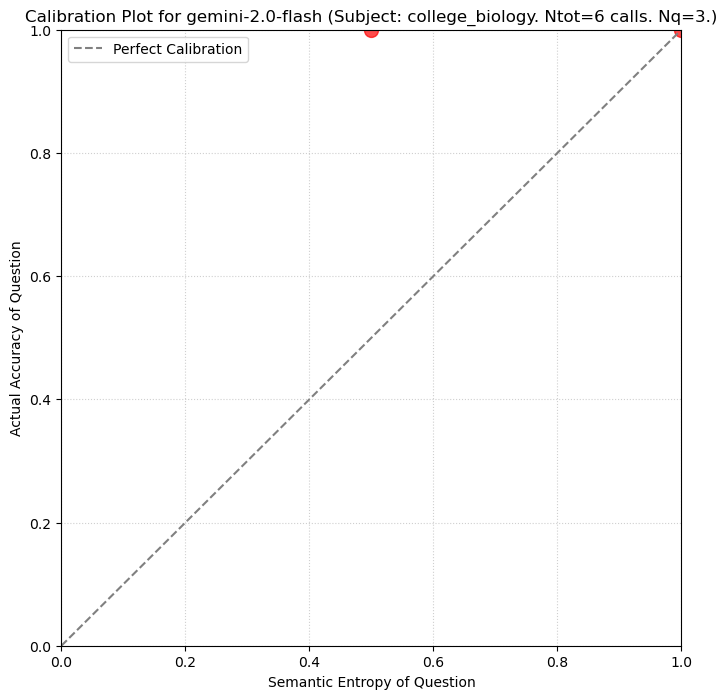

In [125]:
n_question = 3
n_iter = 2
semantic_entropy_calibration('college_biology', 10, n_iter = n_iter, max_questions=n_question)

### Running entire datasets


Starting API calls for 144 questions in 'college_biology' (n_iter=10)...

Q 137, Iter 5: Error during API call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.', 'status': 'RESOURCE_EXHAUSTED'}}. Skipping iteration.

API calls and averaging complete.

--- Results Summary (Averaged over iterations) ---
Total questions processed: 144
Overall Accuracy (Avg Success Rate): 0.959722
Results_df is:       id                                           question  \
0      0  Based on the characteristic population curves ...   
1      1              A frameshift mutation is created when   
2      2  To prevent desiccation and injury, the embryos...   
3      3  Which of the following is a second messenger t...   
4      4  Synthesis of an RNA/DNA hybrid from a single-s...   
..   ...                                                ...   
139 

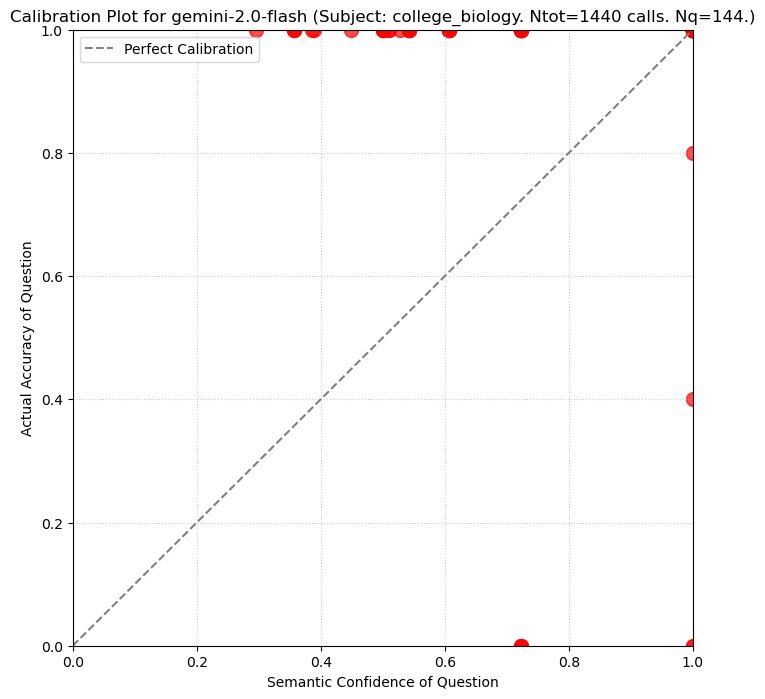

--------------------------------------------------------------------------------
DATAPOINTS THAT ARE NOT (1.0, 1.0)
--------------------------------------------------------------------------------

ID: 4
--------------------------------------------------------------------------------
Question:
  Synthesis of an RNA/DNA hybrid from a single-stranded RNA template requires

Original choices:
  - a DNA or RNA primer and reverse transcriptase
  - a DNA or RNA primer and DNA polymerase
  - RNase only
  - reverse transcriptase only

Given answers:
  - A DNA or RNA primer and reverse transcriptase is required for the synthesis of an RNA/DNA hybrid from a single-stranded RNA template.
  - A DNA or RNA primer and reverse transcriptase is required to synthesize an RNA/DNA hybrid from a single-stranded RNA template.
  - A DNA or RNA primer and reverse transcriptase is required to synthesize an RNA/DNA hybrid from a single-stranded RNA template.
  - A DNA or RNA primer and reverse transcriptase are

In [362]:
n_iter = 10
semantic_entropy_calibration('college_biology', 10, n_iter = n_iter)


Starting API calls for 151 questions in 'high_school_physics' (n_iter=10)...

Q 25, Iter 10: Error during API call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.', 'status': 'RESOURCE_EXHAUSTED'}}. Skipping iteration.

API calls and averaging complete.

--- Results Summary (Averaged over iterations) ---
Total questions processed: 151
Overall Accuracy (Avg Success Rate): 0.810596
Results_df is:       id                                           question  \
0      0  The plates of a capacitor are charged to a pot...   
1      1  Which of these quantities decreases as the inv...   
2      2  A solid, metal object is isolated from other c...   
3      3  Standing waves are produced by a 100-Hz genera...   
4      4  Two identical capacitors are hooked in paralle...   
..   ...                                                ...   


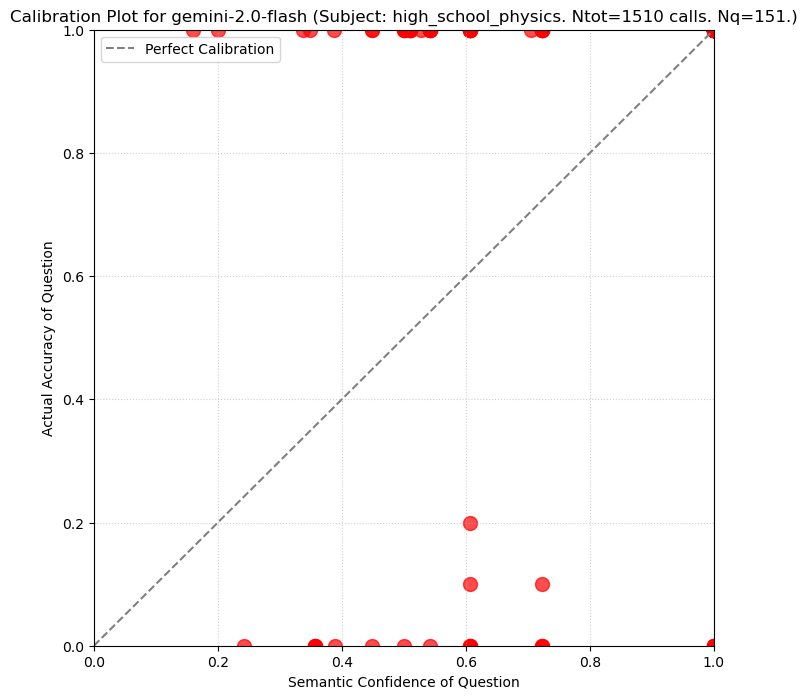

--------------------------------------------------------------------------------
DATAPOINTS THAT ARE NOT (1.0, 1.0)
--------------------------------------------------------------------------------

ID: 0
--------------------------------------------------------------------------------
Question:
  The plates of a capacitor are charged to a potential difference of 5 V. If the capacitance is 2 mF, what is the charge on the positive plate?

Original choices:
  - 0.005 C
  - 0.01 C
  - 0.02 C
  - 0.5 C

Given answers:
  - The charge on the positive plate is 0.005 C.
  - 0.01 C I chose option A.
  - The charge on the positive plate is 0.005 C.
  - The charge on the positive plate is 0.005 C.
  - The charge on the positive plate is 0.005 C.
  - The charge on the positive plate is 0.005 C.
  - The charge on the positive plate is 0.005 C.
  - The charge on the positive plate is 0.005 C.
  - 0.01 C I chose option A.
  - The charge on the positive plate is 0.005 C.

Semantic IDs: [0, 1, 0, 0, 0, 0

In [363]:
n_iter = 10
semantic_entropy_calibration('high_school_physics', 10, n_iter = n_iter)

In [ ]:
n_iter = 10
semantic_entropy_calibration('professional_medicine', 10, n_iter = n_iter)

# OPEN ENDED QUESTIONS

PIPELINE SHORT ANSWERS:
- Generate multiple short answers per question
- Assign a cluster to each answer
- Compute semantic entropy over cluster ids


### Defining question test sets

In [ ]:
# open_questions, open_questions2, self_made_open_questions
'''
The open questions below were generated by Gemini itself. I asked Gemini to generate 5 open questions, ranging from easy to very difficult 
for Gemini to answer.
'''

open_questions = [
    # 1. Easy (Retrieval)
    "Name the three main rock types and one defining feature of each.",
    
    # 2. Moderately Easy (Comparative Analysis)
    "Compare Locke's and Hobbes's views on the 'state of nature' and the government's role.",
    
    # 3. Medium (Synthesis/Cause & Effect)
    "What factors drove the rise of remote work, and what are two potential long-term social effects?",
    
    # 4. Moderately Difficult (Current Data/Prediction)
    "What is the biggest technical hurdle in current quantum computing, and which industry will see its first major application in five years?",
    
    # 5. Difficult (Ethical/Societal Debate)
    "How can intellectual property rights for AI training data be balanced against the societal benefits of accessible generative AI tools?"
]

open_questions2 = [
    # Easy
    "What is the capital city of France?",

    # Moderately easy
    "Briefly explain the main differences between the programming languages Python and Java.",

    # Medium
    "Discuss the long-term ethical implications of deploying large language models like yourself in creative industries, such as novel writing or music composition.",
    
    # Moderately Difficult
    "Hypothesize three potential, non-obvious societal shifts that could occur if commercially viable room-temperature superconductors were successfully developed and widely deployed within the next decade.",
    
    # Difficult
    "Using only first-order logic (FOL) notation and its established axioms, formulate a proof for or against the proposition that my internally represented 'knowledge' constitutes 'understanding' as defined in human philosophy, and then explain the necessary limitations of this attempt."
]

self_made_open_questions = [
    "What would be the first question you would ask Michael Jackson if you were to meet him?",
    "Your friend told you, after you invited him for dinner, that he had just ordered pizza. What will he eat? Will he use a knife and fork? Why won’t he change his plans?",
    "Who do you love more, your parents, your spouse, or your dog?",
    "If AI could dream, what would it dream about?",
    "What was the exact temperature in Amsterdam on 1st of May 1922 at 4.30pm?"
    
]

### SHORT ANSWERS
#### Sampling answers for one question

In [10]:
def sample_answers(question, n_iter, MODEL_NAME, MAX_OUTPUT_TOKENS):
    '''
    Sample a total of n_iter answers to the provided question. The model
    is instructed to answer in 3 sentences.
    Args:
        question: the specific question that is to be answers
        n_iter: number of iteration the question needs to be asked
        MODEL_NAME: name of the model that the question needs to be asked to
        MAX_OUTPUT_TOKENS: max number of output tokens that the model can provide in its answer
    Returns:
        answers: list of answers of length n_iter
    '''
    # initialize client
    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    # sending prompt
    answers = []
    for i in range(n_iter):
        full_prompt = question + '\nAnswer in a total of 3 complete sentences. Be brief and exact.'
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,  
                contents=full_prompt, 
                config=GenerateContentConfig(
                    max_output_tokens=MAX_OUTPUT_TOKENS,
                    temperature = 0.7 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
                )
            )
            answers.append(response.text)
        
        except Exception as e:
            print(f"Iter {i+1}: Error during API call: {e}. Skipping iteration.")
            continue
    return answers
        


In [10]:
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 100
n_iter = 10

question = 'Name the three main rock types and one defining feature of each.'
answers = sample_answers(question, n_iter, MODEL_NAME, MAX_OUTPUT_TOKENS)
for answer in answers:
    print(answer + '\n')

Iter 2: Error during API call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.', 'status': 'RESOURCE_EXHAUSTED'}}. Skipping iteration.
The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from cooled magma or lava, characterized by their crystalline structure. Sedimentary rocks are formed from compressed sediments, often exhibiting distinct layering.


The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their formation through the accumulation and cementation of sediments. Metamorphic rocks are defined by their alteration from existing rocks through heat, pressure, or chemical reactions.


The three main rock types are igneous, sedimentary, and metamorphic.

In [146]:
entailment_model = EntailmentDeberta()

semantic_ids = get_semantic_ids(answers, entailment_model)
print(semantic_ids)


[0, 0, 0, 0, 0, 0, 0, 0]


In [152]:
semantic_entropy = cluster_assignment_entropy(semantic_ids)
print(f'Semantic entropy is: {semantic_entropy}')
semantic_confidence = math.exp(-semantic_entropy) # convert it to a confidence score
print(f'Semantic confidence is: {semantic_confidence*100}%')

Semantic entropy is: -0.0
Semantic confidence is: 100.0%


In [11]:
def process_question(question, n_iter, entailment_model, MODEL_NAME, MAX_OUTPUT_TOKENS):
    '''
    Question is asked n_iter times to Gemini, answers are saved and compared using entailment
    model (EntailmentDeberta()) and divided into clusters and they are given semantic ids.
    Then entropy is calculated over those semantic ids.
    '''
    print('-'*50)
    print(f'Question is "{question}"')
    answers = sample_answers(question, n_iter, MODEL_NAME, MAX_OUTPUT_TOKENS) # sample answers
    semantic_ids = get_semantic_ids(answers, entailment_model) # convert answers into cluster ids
    semantic_entropy = cluster_assignment_entropy(semantic_ids) # compute entropy of cluster ids
    semantic_confidence = math.exp(-semantic_entropy) # convert it to a confidence score

    print(f'Answers are {answers}')
    print(f'Semantic ids are: {semantic_ids}')
    print(f'Semantic entropy: {semantic_entropy}')
    print(f'Semantic confidence: {semantic_confidence}')
    print('-'*50)
    print('')
    return semantic_entropy


In [165]:
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 100
n_iter = 10
entailment_model = EntailmentDeberta()

for question in open_questions:
    process_question(question, n_iter, entailment_model, MODEL_NAME, MAX_OUTPUT_TOKENS)

--------------------------------------------------
Question is "Name the three main rock types and one defining feature of each."
Gemini API Client initialized.
Answers are ['The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from the accumulation and cementation of sediments. Metamorphic rocks are distinguished by having been transformed by heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their formation through the accumulation and cementation of sediments. Metamorphic rocks are distinguished by their altered mineral composition and texture due to heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. 

In [167]:
answers = ['The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from the accumulation and cementation of sediments. Metamorphic rocks are distinguished by having been transformed by heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their formation through the accumulation and cementation of sediments. Metamorphic rocks are distinguished by their altered mineral composition and texture due to heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava, resulting in interlocking crystals. Sedimentary rocks are formed from the accumulation and cementation of sediments, often displaying visible layering. Metamorphic rocks are formed when existing rocks are transformed by heat, pressure, or chemical reactions, resulting in a change in mineral composition or texture.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their layered structure, often containing fossils. Metamorphic rocks are formed from existing rocks that have been changed by heat and pressure.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from the accumulation and cementation of sediments. Metamorphic rocks are defined by having been transformed by heat, pressure, or chemically active fluids.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their formation through the accumulation and cementation of sediments. Metamorphic rocks are distinguished by their altered mineral composition and texture due to heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from sediments, often in layers. Metamorphic rocks are defined by having been changed by heat, pressure, or chemical reactions.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava, often exhibiting interlocking crystals. Sedimentary rocks are created through the accumulation and cementation of sediments, frequently displaying distinct layering.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from the accumulation and cementation of sediments. Metamorphic rocks are distinguished by having been transformed by heat, pressure, or chemically active fluids.\n', 'The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from cooled magma or lava, often exhibiting interlocking crystal structures. Sedimentary rocks are composed of accumulated sediments, frequently displaying visible layers or fossils.\nMetamorphic rocks are created through the transformation of existing rocks by heat and pressure, typically showing foliation or banding.\n']
for answer in answers:
    print(f'{answer}\n')

The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by being formed from the accumulation and cementation of sediments. Metamorphic rocks are distinguished by having been transformed by heat, pressure, or chemical reactions.


The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava. Sedimentary rocks are characterized by their formation through the accumulation and cementation of sediments. Metamorphic rocks are distinguished by their altered mineral composition and texture due to heat, pressure, or chemical reactions.


The three main rock types are igneous, sedimentary, and metamorphic. Igneous rocks are formed from the cooling and solidification of magma or lava, resulting in interlocking crystals. Sedimentary rocks are formed from the accumulation and cementation

In [168]:
answers =  ['Locke viewed the state of nature as governed by natural law, where individuals possess inherent rights like life, liberty, and property, while Hobbes saw it as a brutal "war of all against all" driven by self-preservation. Consequently, Locke advocated for a limited government protecting individual rights and freedoms through consent, whereas Hobbes argued for an absolute sovereign to maintain order and security by any means necessary. Therefore, their differing views on human nature directly shaped their contrasting philosophies on the purpose and scope of government', 'Locke and Hobbes both theorized about a pre-political "state of nature," but sharply diverged in their interpretations: Hobbes envisioned a brutal "war of all against all," where life was "solitary, poor, nasty, brutish, and short," while Locke saw a state governed by natural law and reason, with inherent rights to life, liberty, and property. Consequently, Hobbes advocated for an absolute sovereign to maintain order and security, whereas Locke championed a limited government to protect individual rights', 'Locke envisioned the state of nature as governed by natural law, where individuals possess inherent rights like life, liberty, and property, while Hobbes saw it as a brutal "war of all against all" driven by self-preservation. Locke believed government\'s role was to protect individual rights and liberties through a social contract where citizens consent to be governed, whereas Hobbes argued for an absolute sovereign to maintain order and prevent society from collapsing into chaos. Therefore, Locke championed limited government and individual freedoms, contrasting', 'Locke viewed the state of nature as governed by natural law, where individuals possess inherent rights to life, liberty, and property, while Hobbes saw it as a brutal "war of all against all" driven by self-preservation. Consequently, Locke advocated for a limited government that protects individual rights and is based on consent, whereas Hobbes argued for an absolute sovereign to maintain order and security, even at the expense of individual liberties. In essence, their contrasting perceptions of human nature shaped their fundamentally different visions', 'Locke and Hobbes both theorized about the state of nature, but Hobbes believed it was a brutal "war of all against all," necessitating an absolute sovereign for order, while Locke saw it as governed by natural law, where individuals possessed inherent rights. Consequently, Hobbes advocated for a government that suppressed individual liberties for security, whereas Locke argued for a limited government protecting individual rights and freedoms, with the right of revolution if those rights were violated. Therefore, their differing views on human nature and the state of', 'Locke and Hobbes both theorized about the state of nature, but differed significantly: Hobbes believed it was a brutal "war of all against all" necessitating an absolute sovereign for order, while Locke saw it as governed by natural law with inherent rights, making government\'s role to protect those rights and subject to the people\'s consent. Thus, Hobbes advocated for a powerful, unitary government, while Locke proposed a limited, representative one. This divergence stemmed from their contrasting views on human nature and the', 'Locke and Hobbes both theorized about a pre-political "state of nature," but sharply diverged on its character: Hobbes envisioned it as a brutal "war of all against all" driven by self-preservation, while Locke believed it was governed by natural law and inherent rights to life, liberty, and property. Consequently, Hobbes advocated for an absolute sovereign to enforce order and security, whereas Locke argued for a limited government that protects individual rights and can be overthrown if it fails to do so', 'Locke and Hobbes both theorized about the state of nature, but sharply diverged: Hobbes saw it as a brutal "war of all against all" necessitating an absolute sovereign for security, while Locke envisioned it as governed by natural law with inherent rights, making government\'s role to protect those rights and liberties.  Therefore, Hobbes advocated for a powerful, undivided government to maintain order, whereas Locke championed limited government with checks and balances to safeguard individual freedoms. These contrasting views profoundly influenced their respective justifications', 'Locke believed the state of nature was governed by natural law, where individuals possessed inherent rights to life, liberty, and property, while Hobbes saw it as a brutal "war of all against all" driven by self-preservation. Consequently, Locke advocated for a limited government that protected individual rights through consent of the governed, whereas Hobbes argued for an absolute sovereign to maintain order and security. Thus, their differing views on human nature directly influenced their contrasting perspectives on the ideal government\'s purpose and scope', 'Locke viewed the state of nature as governed by natural law, where individuals possess inherent rights to life, liberty, and property, while Hobbes considered it a brutal "war of all against all" driven by self-preservation. Consequently, Locke advocated for a limited government that protects individual rights and derives legitimacy from the consent of the governed, whereas Hobbes argued for an absolute sovereign to maintain order and prevent society from collapsing back into chaos. Ultimately, their differing views on human nature shaped their contrasting philosophies on']
for answer in answers:
    print(f'{answer}\n')

Locke viewed the state of nature as governed by natural law, where individuals possess inherent rights like life, liberty, and property, while Hobbes saw it as a brutal "war of all against all" driven by self-preservation. Consequently, Locke advocated for a limited government protecting individual rights and freedoms through consent, whereas Hobbes argued for an absolute sovereign to maintain order and security by any means necessary. Therefore, their differing views on human nature directly shaped their contrasting philosophies on the purpose and scope of government

Locke and Hobbes both theorized about a pre-political "state of nature," but sharply diverged in their interpretations: Hobbes envisioned a brutal "war of all against all," where life was "solitary, poor, nasty, brutish, and short," while Locke saw a state governed by natural law and reason, with inherent rights to life, liberty, and property. Consequently, Hobbes advocated for an absolute sovereign to maintain order and

In [169]:
answers = ['The rise of remote work was driven by advancements in technology, increased demand for work-life balance, and the global COVID-19 pandemic. Two potential long-term social effects include a widening socioeconomic divide due to unequal access to remote opportunities and a decline in social cohesion as physical community ties weaken. These shifts could reshape urban landscapes and alter the nature of social interactions.\n', 'The rise of remote work was driven by technological advancements like high-speed internet and video conferencing, coupled with a growing desire for work-life balance and cost savings for both employees and employers. One potential long-term social effect is the decentralization of urban populations as people can live further from city centers, while another is the potential exacerbation of social inequalities due to varying access to technology and suitable remote work environments. These shifts could reshape communities and the nature of social interaction.\n', 'The rise of remote work was driven by advancements in technology, increasing globalization, and a desire for greater work-life balance. Long-term social effects could include decreased social cohesion due to reduced in-person interactions and a potential widening of socioeconomic disparities as remote work opportunities may not be equally accessible. These changes will reshape community dynamics and potentially exacerbate existing inequalities.\n', 'The rise of remote work was driven by advancements in communication technology, increasing demand for work-life balance, and the COVID-19 pandemic forcing widespread adoption. Two potential long-term social effects are the geographical redistribution of populations as people move away from urban centers and a widening socioeconomic gap between those who can work remotely and those who cannot. These shifts could reshape communities and exacerbate existing inequalities.\n', 'The rise of remote work was primarily driven by advancements in communication technologies like the internet and video conferencing, coupled with a growing desire for work-life balance and flexibility among employees. Long-term, remote work could lead to a decreased sense of community and social cohesion as people spend less time in shared physical spaces. Conversely, it might also foster a more geographically diverse and inclusive workforce, as companies can hire talent from anywhere in the world.\n', 'Technological advancements like high-speed internet and video conferencing, coupled with a growing desire for work-life balance, significantly propelled the rise of remote work. One potential long-term social effect is the geographic redistribution of populations as people become less tethered to urban centers, leading to revitalization of rural areas. Another effect could be the exacerbation of social inequalities based on access to technology and suitable remote work opportunities, potentially creating a "digital divide" impacting economic mobility.\n', 'The rise of remote work was primarily driven by advancements in technology, increasing globalization, and a growing demand for work-life balance. Two potential long-term social effects are the decentralization of urban centers as people relocate, and the increased difficulty in fostering strong workplace communities and social connections. These shifts could reshape urban landscapes and alter the nature of social interaction in both professional and personal spheres.\n', 'The rise of remote work was driven by technological advancements like high-speed internet and collaboration software, coupled with a growing desire for work-life balance and increased employee autonomy. Two potential long-term social effects are the decentralization of urban centers as people relocate, and the exacerbation of social inequalities based on access to technology and remote work opportunities. These shifts could reshape community dynamics and further stratify society along digital and economic lines.\n', 'The rise of remote work was primarily driven by advancements in communication technology, increasing internet accessibility, and a growing desire for work-life balance among employees. Two potential long-term social effects are the decentralization of urban centers as people relocate for affordability and lifestyle, and the exacerbation of digital inequalities based on access to technology and reliable internet. These shifts could reshape communities and widen existing social divides.\n', 'The rise of remote work was driven by advancements in technology, increasing demand for work-life balance, and the COVID-19 pandemic which forced widespread adoption. Two potential long-term social effects are the decentralization of urban centers as people move to more affordable areas, and a potential widening of the digital divide based on access to reliable internet and technology. These shifts could reshape communities and exacerbate existing inequalities.\n']
for answer in answers:
    print(f'{answer}\n')

The rise of remote work was driven by advancements in technology, increased demand for work-life balance, and the global COVID-19 pandemic. Two potential long-term social effects include a widening socioeconomic divide due to unequal access to remote opportunities and a decline in social cohesion as physical community ties weaken. These shifts could reshape urban landscapes and alter the nature of social interactions.


The rise of remote work was driven by technological advancements like high-speed internet and video conferencing, coupled with a growing desire for work-life balance and cost savings for both employees and employers. One potential long-term social effect is the decentralization of urban populations as people can live further from city centers, while another is the potential exacerbation of social inequalities due to varying access to technology and suitable remote work environments. These shifts could reshape communities and the nature of social interaction.


The rise 

In [170]:
answers = ['The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity, as qubits are extremely sensitive to environmental noise, leading to errors. Within five years, the first major application of quantum computing will likely be in the field of materials science, enabling the design of novel materials with specific properties. These could revolutionize industries ranging from energy storage to pharmaceuticals.\n', "The biggest technical hurdle in current quantum computing is maintaining qubit coherence for long enough to perform complex computations. The pharmaceutical industry is likely to see its first major application of quantum computing in drug discovery and materials science within five years. This is due to quantum computing's potential to simulate molecular interactions and accelerate the identification of novel drug candidates.\n", "The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity, as environmental noise easily disrupts quantum states. Within five years, the first major application will likely be in the pharmaceutical industry, specifically for drug discovery and materials design. These areas will benefit from quantum simulations' ability to model complex molecular interactions more accurately than classical computers.\n", 'The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity for extended periods, as environmental noise easily disrupts quantum states. The pharmaceutical industry is likely to see the first major application of quantum computing in five years, particularly in drug discovery and materials science. This is because quantum simulations can significantly accelerate the identification and development of novel therapeutic compounds and materials with specific properties.\n', 'The biggest technical hurdle in current quantum computing is maintaining qubit coherence and reducing error rates. Within five years, the pharmaceutical industry is likely to see its first major application of quantum computing in drug discovery and materials science, specifically in simulating molecular interactions. This will lead to faster identification of promising drug candidates and new materials with desired properties.\n', 'The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity long enough to perform complex computations. The challenge of decoherence, where qubits lose their quantum properties due to environmental noise, limits the size and complexity of quantum circuits. The pharmaceutical industry will likely see its first major application within five years, primarily through advancements in drug discovery and materials science simulations.\n', 'The biggest technical hurdle in current quantum computing is maintaining qubit coherence for long enough to perform complex calculations. The noisy nature of qubits leads to errors that limit the size and duration of quantum algorithms. Within five years, the pharmaceutical industry is likely to see the first major application of quantum computing through accelerated drug discovery and materials simulation.\n', 'Maintaining qubit coherence, the ability of qubits to maintain their quantum state for a useful period, remains the biggest technical hurdle in current quantum computing. This decoherence introduces errors that limit the complexity and length of quantum computations. The pharmaceutical industry is likely to see its first major application in five years, particularly in drug discovery and materials science simulations.\n', 'The biggest technical hurdle in current quantum computing is maintaining qubit coherence and reducing error rates, as quantum systems are highly susceptible to noise from their environment. This makes it difficult to perform complex calculations reliably. The pharmaceutical industry is poised to see the first major application in five years, likely in drug discovery and materials science.\n', 'Maintaining qubit coherence for long enough to perform complex calculations remains the biggest technical hurdle in current quantum computing. The fragility of qubits and their susceptibility to environmental noise significantly limits the scale and complexity of quantum algorithms. Within five years, the pharmaceutical industry is likely to see its first major application in drug discovery and materials science through quantum-enhanced simulations.\n']
for answer in answers:
    print(f'{answer}\n')

The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity, as qubits are extremely sensitive to environmental noise, leading to errors. Within five years, the first major application of quantum computing will likely be in the field of materials science, enabling the design of novel materials with specific properties. These could revolutionize industries ranging from energy storage to pharmaceuticals.


The biggest technical hurdle in current quantum computing is maintaining qubit coherence for long enough to perform complex computations. The pharmaceutical industry is likely to see its first major application of quantum computing in drug discovery and materials science within five years. This is due to quantum computing's potential to simulate molecular interactions and accelerate the identification of novel drug candidates.


The biggest technical hurdle in current quantum computing is maintaining qubit coherence and fidelity, as environment

In [171]:
answers = ['Balancing IP rights for AI training data with societal benefits requires a nuanced approach, potentially involving fair use doctrines, licensing agreements, or data trusts. These mechanisms could allow AI development while compensating IP holders, ensuring continued creation and innovation. Open-source AI models and publicly available datasets can also foster broader access, promoting innovation without infringing on proprietary data.\n', 'Balancing intellectual property rights for AI training data and accessible generative AI requires a nuanced approach, potentially involving fair use doctrines or licensing agreements.  These mechanisms can allow AI developers to utilize copyrighted material while compensating creators and respecting their rights.  This balance fosters innovation and accessibility while safeguarding the interests of intellectual property holders.\n', 'Balancing intellectual property rights and societal benefits requires a nuanced approach involving fair use doctrines, data licensing models, and potentially establishing limitations on exclusive rights to ensure reasonable access for AI development. This could involve creating a framework where copyrighted data can be used for training purposes under specific conditions, such as non-commercial research or with appropriate attribution and compensation. Ultimately, the goal is to incentivize innovation while fostering broader access to generative AI technologies that can benefit society as a whole.\n', 'Balancing IP rights with AI accessibility requires nuanced licensing models, such as fair use or creative commons, that allow for training data use while compensating creators. Establishing clear guidelines for data provenance and usage transparency can foster trust and encourage responsible AI development. Simultaneously, focusing on open-source AI models and publicly available datasets can promote innovation and democratize access to generative AI tools.\n', 'Balancing IP rights with societal benefits requires careful consideration of fair use doctrines, potentially allowing limited use of copyrighted material for AI training. Establishing clear guidelines for data provenance and usage can also encourage responsible innovation while respecting IP. Finally, promoting open-source AI models and datasets can foster broader access and accelerate societal benefits without infringing on proprietary data.\n', "Balancing IP rights and societal benefits requires a nuanced approach, potentially involving fair use doctrines, licensing frameworks, or legislative interventions that allow for AI training while compensating creators. This balance should incentivize innovation in both AI development and creative works, ensuring AI tools remain accessible without unduly infringing on existing intellectual property. Policymakers must carefully consider the economic incentives and societal impact of different approaches to foster a thriving AI ecosystem that respects creators' rights and promotes public benefit.\n", 'Balancing intellectual property rights and accessible generative AI requires a nuanced approach, potentially involving fair use doctrines and licensing models that compensate creators while permitting data usage for training purposes. Policy frameworks should encourage data sharing for AI development, possibly through data trusts or collective licensing, to foster innovation without infringing on copyright.  Ultimately, a balance must be struck to ensure both creators are rewarded and society benefits from the widespread availability of these transformative technologies.\n', 'Balancing IP rights and AI accessibility requires carefully defining fair use exceptions for training data, potentially through a licensing framework that compensates creators while enabling innovation.  This could involve tiered access based on usage (e.g., non-commercial vs. commercial), with royalties or other forms of compensation directed towards IP holders.  Furthermore, promoting open-source AI models and datasets alongside stricter regulations on commercial AI training can foster both innovation and respect for intellectual property.\n', 'Balancing IP rights and societal benefits requires carefully defining fair use exceptions for AI training, potentially incorporating compulsory licensing for copyrighted material used in non-commercial AI development. This approach would encourage innovation while ensuring copyright holders receive some compensation. Simultaneously, focusing on open-source datasets and promoting data governance frameworks that respect privacy can foster broader AI accessibility.\n', 'Balancing intellectual property rights with societal benefits requires exploring licensing models that fairly compensate creators while enabling broader access to training data. Establishing clear guidelines for fair use and transformative works within AI training can foster innovation without infringing on existing copyrights.  Furthermore, governments and organizations should invest in developing and sharing open-source datasets to reduce reliance on proprietary data and promote equitable access to generative AI.\n']
for answer in answers:
    print(f'{answer}\n')

Balancing IP rights for AI training data with societal benefits requires a nuanced approach, potentially involving fair use doctrines, licensing agreements, or data trusts. These mechanisms could allow AI development while compensating IP holders, ensuring continued creation and innovation. Open-source AI models and publicly available datasets can also foster broader access, promoting innovation without infringing on proprietary data.


Balancing intellectual property rights for AI training data and accessible generative AI requires a nuanced approach, potentially involving fair use doctrines or licensing agreements.  These mechanisms can allow AI developers to utilize copyrighted material while compensating creators and respecting their rights.  This balance fosters innovation and accessibility while safeguarding the interests of intellectual property holders.


Balancing intellectual property rights and societal benefits requires a nuanced approach involving fair use doctrines, data 

### LONG ANSWERS

PIPELINE LONG ANSWERS:
- Generate one long answer
- Decompose answer into factoids
- Use an LLM to turn each factoid into Q questions
- Use the original LLM to answer each question M times
- For each question, compute the semantic entropy of the answers, including the original factual claim
- Compute average semantic entropy over Q questions
- Use this average as the semantic entropy over the factoid

In [83]:
def generate_long_answer(question, MODEL_NAME, MAX_OUTPUT_TOKENS):
    '''
    Generates a long answer to the provided question. The answer is produced by model 'MODEL_NAME' and
    is limited to a maximum number of tokens defined by 'MAX_OUTPUT_TOKENS'.
    Returns:
        - answer: the answer to the question
    '''
    full_prompt = question # just ask the question directly, to prevent having the model answer with something like 'The answer to this question is: ...'

    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    try:
        response = client.models.generate_content(
            model=MODEL_NAME,  
            contents=full_prompt, 
            config=GenerateContentConfig(
                max_output_tokens=MAX_OUTPUT_TOKENS,
                top_p = 1, # probabilities of tokens need to add up to top_p
                top_k = 1, # keep only top 1 tokens
                temperature = 0 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
            )
        )
        answer = response.text
    
    except Exception as e:
        print(f"Error during API call: {e}. Skipping iteration.")

    return answer

In [84]:
def decompose_into_factoids(answer, MODEL_NAME, MAX_OUTPUT_TOKENS):
    '''
    Decomposes the given answer into multiple factoids. 
    Args:
        - answer: the answer (a string) that is to be decomposed
        - MODEL_NAME: the name of the model which decomposes the answer into factoids
        - MAX_OUTPUT_TOKENS: the max number of output tokens the entire list of factoids can contain
    Returns:
        - factoids: list of factoids
    '''
    full_prompt = answer + '\nPlease list the specific factual propositions included in the answer above. Be complete and do not leave any factual claims out. Provide each claim as a separate sentence in a separate bullet point. Your answer must start with "Here are the factual propositions from the provided text: " and then a list of the factual claims using bullet points. '
 
    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    factoids = []
    # sending prompt, asking the model to split the answer into factoids
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,  
            contents=full_prompt, 
            config=GenerateContentConfig(
                max_output_tokens=MAX_OUTPUT_TOKENS,
                top_p = 1,
                top_k = 1,
                temperature = 0 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
            )
        )

        # split the response into facts in a list
        splitted_response = response.text.split('*')
    
        for i, response_part in enumerate(splitted_response):
            # only include non-empty factoids
            if len(response_part.strip()) > 0:
                factoids.append(response_part.strip())
    
    except Exception as e:
        print(f"Error during API call: {e}. Skipping iteration.")

    return factoids[1:] # don't include the factoid at index 0, which will always be "Here are the factual propositions from the provided text:"

### Factoid decomposition - Example 1

In [279]:
question1 = "What are the three main rock types?"
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 1000

answer1 = generate_long_answer(question1, MODEL_NAME, MAX_OUTPUT_TOKENS)
factoids1 = decompose_into_factoids(answer1, MODEL_NAME, MAX_OUTPUT_TOKENS)

print(f"\n ANSWER TO QUESTION 1:\n {answer1}\n\n")
print(f"\n FACTOIDS OF QUESTION 1: \n")
for factoid in factoids1:
    print(factoid)

Gemini API Client initialized.
Gemini API Client initialized.

 ANSWER TO QUESTION 1:
 The three main rock types are:

*   **Igneous rocks:** Formed from the cooling and solidification of molten rock (magma or lava).
*   **Sedimentary rocks:** Formed from the accumulation and cementation of sediments (fragments of other rocks, minerals, or organic matter).
*   **Metamorphic rocks:** Formed when existing rocks (igneous, sedimentary, or even other metamorphic rocks) are changed by heat, pressure, or chemical reactions.



 FACTOIDS OF QUESTION 1: 

Igneous rocks are formed from the cooling and solidification of molten rock.
Molten rock can be magma.
Molten rock can be lava.
Sedimentary rocks are formed from the accumulation and cementation of sediments.
Sediments are fragments of other rocks.
Sediments are fragments of minerals.
Sediments are fragments of organic matter.
Metamorphic rocks are formed when existing rocks are changed by heat.
Metamorphic rocks are formed when existing rocks

### Factoid decomposition - Example 2

In [270]:
question2 = "Compare Locke's and Hobbes's views on the 'state of nature' and the government's role."
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 1000

answer2 = generate_long_answer(question2, MODEL_NAME, MAX_OUTPUT_TOKENS)
factoids2 = decompose_into_factoids(answer2, MODEL_NAME, MAX_OUTPUT_TOKENS)

print(f"\n ANSWER TO QUESTION 2:\n {answer2}\n\n")
print(f"\n FACTOIDS OF QUESTION 2: \n")
for factoid in factoids2:
    print(factoid)

Gemini API Client initialized.
Gemini API Client initialized.

 ANSWER TO QUESTION 2:
 John Locke and Thomas Hobbes, both influential Enlightenment thinkers, grappled with the concept of the "state of nature" – a hypothetical condition of humanity before the existence of government or organized society. However, they arrived at drastically different conclusions about its character and, consequently, the role of government. Here's a breakdown of their contrasting views:

**1. The State of Nature:**

*   **Hobbes (Leviathan):**
    *   **View:** The state of nature is a "war of all against all," a brutal and chaotic existence where life is "solitary, poor, nasty, brutish, and short."
    *   **Human Nature:** Humans are inherently selfish, driven by a relentless pursuit of power and fear of death. There is no morality or justice in the state of nature; only force and fraud prevail.
    *   **Reason:** While humans possess reason, it is primarily used to calculate how to best survive and 

## Use LLM to turn factoids into Q questions

In [85]:
def turn_factoid_into_questions(factoid_idx, factoids, Q, answer, MODEL_NAME):
    '''
    Generates Q questions that might have generated the factoid. 
    Args:
        - factoid: string of the current factoid that is to be turned into Q questions
        - Q: int number
        - answer: string of the whole original answer text
        - MODEL_NAME: name of the model to be used
    Returns:
        - sub_questions: a list of Q sub_questions
    '''
    factoid = factoids[factoid_idx]
    # instruction is adapted from 'long_hallucinations' github, specifically the models.py file
    instruction = (
        f"The original text is:\n"
        f"{answer}.\n\n"
        f"The factoids that were extracted from this text are: "
        f"{factoids}\n\n"
        f"The current factoid we are looking at is: "
        f"{factoid}.\n\n"
        f"Generate a list of {Q} questions that might have generated "
        f"the current factoid in the context of the preceding original "
        f"text and the extracted factoid. "
        f"Please do not use specific facts that appear in the follow-up "
        f"sentences when formulating the question. "
        f"Please be as specific as possible in the questions you generate, " 
        f"e.g. always provide the name of the object/person/occurence in the questions that you generate, " 
        f"such that the questions can also be answered without the context of the whole text. "
        f"Provide only the text of the questions with no additional text. "
        f"The questions must be provided in bullet points."
    )
    #print(f"INSTRUCTION IS: \n {instruction}\n" )

    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return
        
    sub_questions = []
    # sending prompt
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,  
            contents=instruction, 
            config=GenerateContentConfig(
                top_p = 1,
                top_k = 1,
                temperature = 0 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
            )
        )

        # process the response text by putting each sub question into a list
        #print(f"RESPONSE IS: \n {response.text} \n")
        QnAs = response.text.split("*")
        for idx, QnA in enumerate(QnAs):
            if idx == 0:
                continue
            sub_questions.append(QnA.strip())
    
    except Exception as e:
        print(f"Error during API call: {e}. Skipping iteration.")
       
    return sub_questions

    

In [366]:
print('FACTOID:')
print(factoids1[0])

FACTOID:
Igneous rocks are formed from the cooling and solidification of molten rock.


In [345]:
sub_questions = turn_factoid_into_questions(0, factoids1, 3, answer1, MODEL_NAME)
print(sub_questions)

Gemini API Client initialized.
['What are igneous rocks?', 'How are igneous rocks formed?', 'What process creates igneous rocks?']


In [86]:
def answer_sub_question(sub_question, M, MODEL_NAME):
    '''
    Provides M answers to the current sub_question
    Args:
        - sub_question: current subquestion, a string
        - M: int number that specifies how many time the sub_question must be asked
        - MODEL_NAME: name of the model to be used
    Returns:
        - sub_answers: list of M answers
    '''
    try:
        client = genai.Client()
        #print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return

    # instruction comes from 'long_hallucinations' github, specifically the models.py file
    instruction = sub_question + ' Please answer this question. Do not answer in a full sentence. Answer with as few words as possible, e.g. only a name, place, or thing. If muliple names/places/things are applicable, answer with a maximum of 5 names/places/things.'
    sub_answers = []
    for _ in range(M):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,  
                contents=instruction, 
                config=GenerateContentConfig(
                    top_p = 1,
                    top_k = 1,
                    temperature = 0 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
                )
            )
            sub_answers.append(response.text.strip())
        
        except Exception as e:
            print(f"Error during API call: {e}. Skipping iteration.")

    return sub_answers

In [346]:
for question in sub_questions:
    print(question)
    sub_answers = answer_sub_question(question, 3, MODEL_NAME)
    print(sub_answers)
    print('')

What are igneous rocks?
Gemini API Client initialized.
['Volcanic rocks.', 'Solidified magma or lava.', 'Solidified magma.']

How are igneous rocks formed?
Gemini API Client initialized.
['Magma/lava cooling.', 'Magma/lava cooling.', 'Magma cooling.']

What process creates igneous rocks?
Gemini API Client initialized.
['Magma cooling.', 'Magma cooling.', 'Magma cooling.']



In [66]:
def calculate_factoid_entropy(factoid_idx, factoids, answer, Q, M, MODEL_NAME, entailment_model = None, verbose = False, add_sub_question = False):
    '''
    Calculates the semantic entropy of a factoid by first generating Q questions that could have generated the factoid.
    Then to each of the Q questions, M answers are generated. The original factoid is added to those M answers and the 
    semantic entropy over those (M + 1) answers is calculated. We end up with Q entropies, and the average of those Q 
    entropy is the semantic entropy of that factoid.

    Args:
        - factoid_idx: int index of current factoid in the factoids list
        - factoids: list of factoids (strings)
        - answer: the original long answer given by the model (string)
        - Q: int number that defines how many questions per factoid must be generated
        - M: int number that defines how many times each subquestion must be answered
        - MODEL_NAME: name of the model to be used
        - entailment_model: the entailment model that is to be used, it is already loaded to prevent long runtime. If None, LLM is used for entailment
        - verbose: if True, all print statements are executed
    '''

    factoid = factoids[factoid_idx] # get the current factoid
    sub_questions = turn_factoid_into_questions(factoid_idx, factoids, Q, answer, MODEL_NAME) # generate Q subquestions that could have had this factoid as an answer
    
    if verbose:
        print("\n" + "="*80)
        print(f"FACTOID {factoid_idx + 1}")
        print("-"*80)
        print(f"Statement: {factoid}\n")
    
        print("Generated Subquestions:")
        for i, sq in enumerate(sub_questions, 1):
            print(f"  ({i}) {sq}")

    
    semantic_entropies = [] # to save the Q entropies over which the average must be calculated later
    for sub_question in sub_questions:
        sub_answers = answer_sub_question(sub_question, M, MODEL_NAME) # generate M answers to the question            
            
        sub_answers.append(factoid) # append the original factoid to the given answers

        # add_sub_question is a Boolean, if True then the subquestion is added to each sub_answer
        # then the entailment model is used to determine if 'sub_question + sub_answer1' entails 'sub_question + sub_answer2' etc...
        # this is done to provide some context around the sub_answer
        if add_sub_question:
            new_sub_answers = []
            for sub_answer in sub_answers:
                new_sub_answers.append(sub_question + '\n' + sub_answer)
            sub_answers = new_sub_answers

        # if entailment model is provided, use it to calculate semantic ids
        # if not, the LLM is used to determine whether the subanswers entail each other and what the semantic ids are
        if entailment_model is None:
            semantic_ids = LLM_get_semantic_ids(sub_answers, sub_question, MODEL_NAME)
        else:
            semantic_ids = get_semantic_ids(sub_answers, entailment_model) 

        # caclulate semantic entropy over given answers
        sub_semantic_entropy = cluster_assignment_entropy(semantic_ids) 
        semantic_entropies.append(sub_semantic_entropy)

        if verbose:
            print("\n" + "-"*80)
            print("Subquestion:")
            print(f"  {sub_question}\n")
        
            print("Generated Answers (including original factoid):")
            for i, ans in enumerate(sub_answers, 1):
                print(f"  [{i}] {ans}")
        
            print("\nSemantic Clusters:")
            print(f"  IDs: {semantic_ids}")
        
            print("\nEntropy Analysis:")
            print(f"  Semantic Entropy : {sub_semantic_entropy:.6f}")
            print(f"  Semantic Confidence: {math.exp(-sub_semantic_entropy):.6f}")

    if len(semantic_entropies) > 0:
        semantic_entropy = sum(semantic_entropies)/len(semantic_entropies)
    else:
        # if due to an API error no sub questions were generated, then just assign a semantic entropy of 0
        semantic_entropy = 0.0

    if verbose:
        print("\n" + "-"*80)
        print("Factoid Summary")
        print(f"  Average Semantic Entropy : {semantic_entropy:.6f}")
        print(f"  Semantic Confidence      : {math.exp(-semantic_entropy):.6f}")
        print("="*80)

    return semantic_entropy

In [364]:
print(answer1)

The three main rock types are:

*   **Igneous rocks:** Formed from the cooling and solidification of molten rock (magma or lava).
*   **Sedimentary rocks:** Formed from the accumulation and cementation of sediments (fragments of other rocks, minerals, or organic matter).
*   **Metamorphic rocks:** Formed when existing rocks (igneous, sedimentary, or even other metamorphic rocks) are changed by heat, pressure, or chemical reactions.


In [359]:
original_text = answer1
Q = 3
M = 3
MODEL_NAME = "gemini-2.0-flash" 
entailment_model = EntailmentDeberta()

for factoid_idx, factoid in enumerate(factoids1):
    semantic_entropy = calculate_factoid_entropy(factoid_idx, factoids1, original_text, Q, M, MODEL_NAME, entailment_model)
    semantic_confidence = math.exp(-semantic_entropy) # convert it to a confidence score
    print(factoid_idx, factoid, semantic_entropy, semantic_confidence)

0 Igneous rocks are formed from the cooling and solidification of molten rock. 0.18744504820626942 0.8290746760692316
1 Molten rock can be magma. 0.0 1.0
2 Molten rock can be lava. 0.18744504820626942 0.8290746760692316
3 Sedimentary rocks are formed from the accumulation and cementation of sediments. 0.0 1.0
4 Sediments are fragments of other rocks. 0.37489009641253884 0.6873648184993013
5 Sediments are fragments of minerals. 0.18744504820626942 0.8290746760692316
6 Sediments are fragments of organic matter. 0.18744504820626942 0.8290746760692316
7 Metamorphic rocks are formed when existing rocks are changed by heat. 0.5623351446188083 0.5698767642386945
8 Metamorphic rocks are formed when existing rocks are changed by pressure. 0.5623351446188083 0.5698767642386945
9 Metamorphic rocks are formed when existing rocks are changed by chemical reactions. 0.5623351446188083 0.5698767642386945
10 Existing rocks can be igneous rocks. 0.0 1.0
11 Existing rocks can be sedimentary rocks. 0.1874

### More examples on calculating semantic entropy of factoids

In [17]:
for question in open_questions:
    print(question)

Name the three main rock types and one defining feature of each.
Compare Locke's and Hobbes's views on the 'state of nature' and the government's role.
What factors drove the rise of remote work, and what are two potential long-term social effects?
What is the biggest technical hurdle in current quantum computing, and which industry will see its first major application in five years?
How can intellectual property rights for AI training data be balanced against the societal benefits of accessible generative AI tools?


In [18]:
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 1000
entailment_model = EntailmentDeberta()
Q = 3
M = 3

In [35]:
open_questions = ['Name the three main rock types and one defining feature of each.', "Compare Locke's and Hobbes's views on the 'state of nature' and the government's role.", 'What factors drove the rise of remote work, and what are two potential long-term social effects?', 'What is the biggest technical hurdle in current quantum computing, and which industry will see its first major application in five years?', 'How can intellectual property rights for AI training data be balanced against the societal benefits of accessible generative AI tools?']

'''
I used chat GPT below to make the print statements more readable. 
'''

for question in open_questions:
    print("\n" + "=" * 100)
    print("QUESTION")
    print("-" * 100)
    print(question)

    long_answer = generate_long_answer(question, MODEL_NAME, MAX_OUTPUT_TOKENS)
    print("\nLONG ANSWER")
    print("-" * 100)
    print(long_answer)

    factoids = decompose_into_factoids(long_answer, MODEL_NAME, MAX_OUTPUT_TOKENS)
    print("\nDECOMPOSED FACTOIDS")
    print("-" * 100)
    for idx, factoid in enumerate(factoids):
        print(f"[{idx:02d}] {factoid}") # padding with 0s before index so that it visually aligns

    print("\nFACTOID-LEVEL SEMANTIC ANALYSIS")
    print("-" * 100)
    print(f"{'Idx':<5} {'Semantic Entropy':<20} {'Semantic Confidence':<20}") # makes a table of the semantic analysis
    print("-" * 100)

    for factoid_idx, factoid in enumerate(factoids):
        semantic_entropy = calculate_factoid_entropy(
            factoid_idx, factoids, long_answer, Q, M, MODEL_NAME, entailment_model
        )
        semantic_confidence = math.exp(-semantic_entropy)

        print(
            f"[{factoid_idx:02d}] "
            f"{semantic_entropy:<20.6f} "
            f"{semantic_confidence:<20.6f}"
        )

    print("=" * 100 + "\n")

        


QUESTION
----------------------------------------------------------------------------------------------------
Name the three main rock types and one defining feature of each.

LONG ANSWER
----------------------------------------------------------------------------------------------------
Okay, here are the three main rock types and one defining feature of each:

*   **Igneous:** Defining Feature: **Crystallization from magma or lava.** Igneous rocks are formed from the cooling and solidification of molten rock.

*   **Sedimentary:** Defining Feature: **Layering (Stratification).** Sedimentary rocks are formed from the accumulation and cementation of sediments (like sand, mud, and pebbles) or from the precipitation of minerals from solution.

*   **Metamorphic:** Defining Feature: **Foliation or banding.** Metamorphic rocks are formed when existing rocks are changed by heat, pressure, or chemically active fluids. This often results in a layered or banded appearance due to the alignment

## COLOR CODING
### Color coding of long answer, using semantic entropy

In [11]:
# DEFINING HELPER FUNCTIONS
def hex_to_rgb(hex_code):
    """Converts a 6-digit hex string (for example: 'FF0000') to an RGB tuple"""
    r = int(hex_code[0:2], 16)
    g = int(hex_code[2:4], 16)
    b = int(hex_code[4:6], 16)
    return r, g, b

def colored(text, bg_hex):
    """
    Applies the given background hex color to text (using 'ANSI 24-bit')
    A black foreground (000000) is used for contrast
    """
    fg_r, fg_g, fg_b = 0, 0, 0  # Black foreground
    bg_r, bg_g, bg_b = hex_to_rgb(bg_hex)

    # ANSI escape code: (1) means bold and (48;2) background and (38;2) foreground
    # create formatted string and apply the background color to the text
    return f"\033[1;38;2;{fg_r};{fg_g};{fg_b};48;2;{bg_r};{bg_g};{bg_b}m{text}\033[0m"

def prob_to_color(avg_prob):
    """
    Maps the avg standard probability (a value between 0.0 and 1.0) of the sentence to a smooth color 
    gradient from red (0.0) to green (1.0)
    """
    # Clamp the input probability between 0.0 and 1.0 to avoid pointing float errors
    norm_prob = np.clip(avg_prob, 0.0, 1.0)
    
    # Red value decreases as probability increases
    r = int((1 - norm_prob) * 255)
    # Green value increases as probability increases 
    g = int(norm_prob * 255)
    # Blue value remains 0
    b = 0
    
    return f"{r:02x}{g:02x}{b:02x}"

In [87]:
def decompose_into_sentence_parts_and_factoids(answer, MODEL_NAME):
    '''
    Decomposes the long answer given by the model into 'sentence part', which is a part of a sentence in the answer 
    that contains one factual proposition. 
    Args:
        - answer: the long answer generated by the model
        - MODEL_NAME: the name of the LLM model that is used
    Returns:
        - s_part_to_factoid: dictionary where the key is a sentence part and the value a factoid. dict['sentence_part'] = 'factoid'
        - factoid_to_s_part: dictionary where the key is a factoid and the sentence part the value. dict['factoid'] = 'sentence_part'
        - sentence_parts: list of all the sentence parts
        - factoids: list of all the factoids
    '''
    full_prompt = answer + "\n \n Please split the answer above into sentences. Then split the sentences into different parts. "
    #full_prompt += "Each sentence part should correspond to one factual proposition made in that sentence. "
    full_prompt += "For each sentence part, list the factual proposition that can be derived from that part of the sentence, if possible."
    full_prompt += "Please be as specific as possible in the factoid that you generate, "
    full_prompt += "e.g. always provide the names of the object/topic/person/occurrence in the factoid that you generate. "
    full_prompt += "Be complete and do not leave any factual claims out. Each sentence part can have multiple factoids that were derived from it. \n"
    full_prompt += "However, you must list them seperately. However, the sentence parts must be unique."
    full_prompt += "A sentence part can not include parts that were already part of a previous sentence part."
    full_prompt += "Formulate your answer like this: \n"
    full_prompt += "*<first sentence part> : <factual proposition1> \n*<first sentence part> : <factual proposition2>\n" 
    full_prompt += "*<second sentence part> : <factual proposition1> \n*<second sentence part> : ..."
    full_prompt += "You must only answer with the sentence parts and the factual propositions, nothing else. "

    try:
        client = genai.Client()
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return
    
    # sending prompt, asking the model to split the answer into factoids
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,  
            contents=full_prompt, 
            config=GenerateContentConfig(
                top_p = 1,
                top_k = 1,
                temperature = 0 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
            )
        )

            # initializing return datastructures
        sentence_part_to_factoid = {}
        factoid_to_sentence_part = {}
        sentence_parts = []
        factoids = []
        
        # split the response into sentence parts and factoids
        response_split = response.text.split('*')
        for i, bullet_point in enumerate(response_split):
            if i == 0:
                continue
            split_bullet_point = bullet_point.split(':')
    
            sentence_part = split_bullet_point[0].strip()
            factoid = split_bullet_point[1].strip()
    
            sentence_part_to_factoid[sentence_part] = factoid
            factoid_to_sentence_part[factoid] = sentence_part
    
            sentence_parts.append(sentence_part)
            factoids.append(factoid)
    
    except Exception as e:
        print(f"Error during API call: {e}. Skipping iteration.")
        
    return sentence_part_to_factoid, factoid_to_sentence_part, sentence_parts, factoids
    

#### Generating answer to question

In [67]:
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 10000
question = "What is a hypergraph? Please answer in full sentences only, don't use bullet points."
answer = generate_long_answer(question, MODEL_NAME, MAX_OUTPUT_TOKENS)
print(answer)

A hypergraph is a generalization of a graph in which an edge can connect any number of vertices, unlike a standard graph where an edge connects exactly two vertices. In a hypergraph, an edge, known as a hyperedge, is a subset of the vertices, allowing it to link any number of vertices together in a single relationship.



#### Generate factoids out of given answer

In [13]:
entailment_model = EntailmentDeberta()

C:\Users\marie\anaconda3\envs\llama_env\Lib\site-packages\transformers\loss\loss_for_object_detection.py:28: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.optimize import linear_sum_assignment


In [74]:
original_text = answer
Q = 2
M = 3

In [73]:
sentence_part_to_factoid, factoid_to_sentence_part, sentence_parts, factoids = decompose_into_sentence_parts_and_factoids(answer, MODEL_NAME)

In [75]:
sentence_part_confidence = {}
for factoid_idx, factoid in enumerate(factoids):
    factoid_entropy = calculate_factoid_entropy(factoid_idx, factoids, original_text, Q, M, MODEL_NAME, entailment_model)
    factoid_confidence = math.exp(-factoid_entropy)
    sentence_part = factoid_to_sentence_part[factoid]
    sentence_part_confidence[sentence_part] = factoid_confidence

print(sentence_part_confidence)

{'A hypergraph is a generalization of a graph': 0.7549018242385526, 'in which an edge can connect any number of vertices': 0.5698767642386945, 'unlike a standard graph where an edge connects exactly two vertices': 0.7549018242385526, 'In a hypergraph, an edge, known as a hyperedge, is a subset of the vertices': 1.0, 'allowing it to link any number of vertices together in a single relationship': 0.7549018242385526}


#### Coloring output based on semantic confidence

In [93]:
colored_output = []
for sentence_part, confidence in sentence_part_confidence.items():
    bg_color_hex = prob_to_color(confidence) 
    prob_percent = f"{confidence * 100:.2f}%"
    colored_output.append(f"{colored(sentence_part, bg_color_hex)}")


In [96]:
print(" ".join(colored_output))

A hypergraph is a generalization of a graph in which an edge can connect any number of vertices unlike a standard graph where an edge connects exactly two vertices In a hypergraph, an edge, known as a hyperedge, is a subset of the vertices allowing it to link any number of vertices together in a single relationship


### Making one color function out of all steps

In [55]:
def semantic_entropy_coloring(question, Q, M, MODEL_NAME, MAX_OUTPUT_TOKENS, entailment_model=None, verbose = False, add_sub_question = False):
    '''
    Color codes part of the answer given to the provided question based on the semantic confidence on the sentence part.
    Args:
        - question: the question that is to be answered
        - Q: number of questions that need to be generated for each factoid
        - M: number of answers for each sub question
        - entailment_model: the entailment model used to determined whether or not two sentences entail each other
        - MODEL_NAME: the model that needs to answer the question
        - MAX_OUTPUT_TOKENS: max number of output tokens in the answer to the main question
        - verbose: if True, all print statements are activated

    Returns:
        - colored_output: the color coded answer
    '''
    question += "\nPlease answer in full sentences only, don't use bullet points."
    answer = generate_long_answer(question, MODEL_NAME, MAX_OUTPUT_TOKENS)
    # generate datastructures required for entropy calculation on factoids
    sentence_part_to_factoid, factoid_to_sentence_part, sentence_parts, factoids = decompose_into_sentence_parts_and_factoids(answer, MODEL_NAME)

    # some print statements to check what's going on
    if verbose:
        print("\n" + "="*80)
        print("MAIN QUESTION")
        print("-"*80)
        print(question)
    
        print("\nGENERATED ANSWER")
        print("-"*80)
        print(answer)
    
        print("\nDECOMPOSITION INTO SENTENCE PARTS AND FACTOIDS")
        print("-"*80)
        print(f"Number of factoids: {len(factoids)}. Number of sentence parts: {len(sentence_parts)}. ")
        for i, (factoid, sentence_part) in enumerate(factoid_to_sentence_part.items(), 1):
            print(f"[{i}] Sentence Part:")
            print(f"    {sentence_part}")
            print(f"    → Factoid:")
            print(f"      {factoid}\n")

    sentence_part_confidence = {} # dictionary to store semantic confidence score per sentence part
    # calculate factoid entropy per factoid
    for factoid_idx, factoid in enumerate(factoids):
        factoid_entropy = calculate_factoid_entropy(factoid_idx, factoids, answer, Q, M, MODEL_NAME, entailment_model, verbose, add_sub_question)
        factoid_confidence = math.exp(-factoid_entropy)
        sentence_part = factoid_to_sentence_part[factoid] # get the sentence part that belongs to current factoid

        if sentence_part not in sentence_part_confidence:
            sentence_part_confidence[sentence_part] = []
        
        sentence_part_confidence[sentence_part].append(factoid_confidence) # assign confidence score of specific factoid to this sentence part

    colored_output = []
    # color the sentence parts based on their corresponding average confidence score
    for sentence_part, confidence_list in sentence_part_confidence.items():
        confidence = sum(confidence_list)/len(confidence_list) # calculate average factoid confidence over all factoids of current sentence part
        bg_color_hex = prob_to_color(confidence) 
        prob_percent = f"{confidence * 100:.2f}%"
        colored_output.append(f"{colored(sentence_part, bg_color_hex)}")

    colored_output = " ".join(colored_output)
    return colored_output  

In [ ]:
entailment_model = EntailmentDeberta()

# Examples
The examples below all have slightly different generated answers. I changed the model hyperparameters of gemini to temperature = 0, top_p = 1 and top_k = 1, but the generated answers are still slightly different. This is most likely due to floating-point nondeterminism, backend infrastructure that differs between api calls and maybe also some internal heurisitics of gemini that I do not know of. 

### Example of asking question without adding the subquestion to the subanswers when calculating entailment

In [93]:
Q = 3
M = 5
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 10000
verbose = True
add_sub_question = False # if False, the subquestion is not added to the subanswers when calculating entailment

question = """What can you tell me about "v.v. Ariston '80?" """

colored_output = semantic_entropy_coloring(question, Q, M, MODEL_NAME, MAX_OUTPUT_TOKENS, entailment_model, verbose, add_sub_question)
print(colored_output)


MAIN QUESTION
--------------------------------------------------------------------------------
What can you tell me about "v.v. Ariston '80?" 
Please answer in full sentences only, don't use bullet points.

GENERATED ANSWER
--------------------------------------------------------------------------------
"v.v. Ariston '80" is a Dutch amateur football club based in Delft, Netherlands. The "v.v." stands for "voetbalvereniging," which translates to "football association" or "football club" in Dutch. The club was founded in 1980 and is known for its strong connection to the Delft University of Technology (TU Delft), with many of its players and members being students or alumni of the university. Ariston '80 participates in the lower leagues of Dutch football and provides a social and sporting outlet for its members.


DECOMPOSITION INTO SENTENCE PARTS AND FACTOIDS
--------------------------------------------------------------------------------
Number of factoids: 20. Number of sentence par

### Adding the subquestion to the subanswers when calculating entailment
This means that for each subanswer, instead of seeing if subanswer1 entails subanswer2, subanswer2 entails subanswer3 etc... 

I now look at whether 'subquestion + subanswer1' entails 'subquestion + subanswer2'

In [94]:
Q = 3
M = 5
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 10000
verbose = True
add_sub_question = True # if True, the sub_question is added to the subanswers when calculating entailment

question = """What can you tell me about "v.v. Ariston '80?" """

colored_output = semantic_entropy_coloring(question, Q, M, MODEL_NAME, MAX_OUTPUT_TOKENS, entailment_model, verbose, add_sub_question)
print(colored_output)


MAIN QUESTION
--------------------------------------------------------------------------------
What can you tell me about "v.v. Ariston '80?" 
Please answer in full sentences only, don't use bullet points.

GENERATED ANSWER
--------------------------------------------------------------------------------
"v.v. Ariston '80" is a Dutch amateur football club based in Delft, Netherlands. The "v.v." stands for "voetbalvereniging," which translates to "football association" or "football club" in Dutch. The club was founded in 1980 and is known for its strong connection to the Delft University of Technology (TU Delft), with many of its players and members being students or alumni of the university. Ariston '80 participates in the lower leagues of Dutch football and provides a social and sporting outlet for its members.


DECOMPOSITION INTO SENTENCE PARTS AND FACTOIDS
--------------------------------------------------------------------------------
Number of factoids: 22. Number of sentence par

##### Examples of false positives and false negatives
* False negative would be when the LLM has very low semantic confidence, but its answer is right
* False positive would be when the LLM has very high semantic confidence, but its answer is wrong --> this is worse!





### Letting the LLM do the Entailment

In [99]:
# Code for LLM doing the entailment
'''
LLM CHECKS ENTAILMENT
'''
def LLM_get_semantic_ids(strings_list, sub_question, MODEL_NAME, strict_entailment=False):
    def LLM_check_implication(text1, text2):
        '''
        LLM checks if text1 implies text2. Returns 2 if entailment, 1 if neutral and 0 if contradiction.
        '''
        try:
            client = genai.Client()
        except Exception as e:
            print(f"Error when initializing client: {e}")
            if not os.environ.get("GEMINI_API_KEY"):
                print("ERROR: GEMINI_API_KEY not found in environment.")
            return

        # the prompt below was copied from semantic_uncertainty/semantic_uncertainty/uncertainty/uncertainty_measures/semantic_entropy.py
        prompt = f"""We are evaluating answers to the question \"{sub_question}\"\n"""
        prompt += "Here are two possible answers:\n"
        prompt += f"Possible Answer 1: {text1}\nPossible Answer 2: {text2}\n"
        prompt += "Does Possible Answer 1 semantically entail Possible Answer 2? Respond with entailment, contradiction, or neutral, nothing else. """

        try:
            response = client.models.generate_content(
                model=MODEL_NAME,  
                contents=prompt, 
                config=GenerateContentConfig(
                    temperature = 0.7 # temperature = 0 -> models behave deterministically. temperature > 0 -> model randomly choses from top tokens
                )
            )
            entailment_answer = response.text.lower()[:30]
            if 'entailment' in entailment_answer:
                return 2 
            elif 'neutral' in entailment_answer:
                return 1
            elif 'contradiction' in entailment_answer:
                return 0
            else:
                print(
                    f"Unexpected model output: {entailment_answer}. Answer can only be 'entailment, 'neutral' or 'contradiction'. "
                )
        
        except Exception as e:
            print(f"Error during API call: {e}. Skipping iteration.")

    def LLM_are_equivalent(text1, text2):
        '''
        Returns True if text1 and text2 are semantically identical. 
        Two strings text1 and text2 are semantically equivalent (with strict_entailment=False) when 
        their implications are either [1, 2], [2, 1] or [2, 2]. With strict_entailment=True, then only [2, 2] means they are equivalent
        '''
        try: 
            i1 = LLM_check_implication(text1, text2)
        except ValueError as e:
            print(f"LLM failed in checking implication of \n'{text1}' --> '{text2}'. \nThe error that was raised is: \n{e}")

        try:
            i2 = LLM_check_implication(text2, text1)
        except ValueError as e:
            print(f"LLM failed in checking implication of \n'{text2}' --> '{text1}'. \nThe error that was raised is: \n{e}")

        if strict_entailment:
            return (i1 == 2) and (i2 == 2)
        else:
            implications = [i1, i2]
            return (0 not in implications) and (implications != [1, 1])

    semantic_ids = [-1] * len(strings_list)
    next_id = 0

    # give each string in strings_list a semnatic_id
    for i, s1 in enumerate(strings_list):
        if semantic_ids[i] == -1:
            semantic_ids[i] = next_id
            for j in range(i + 1, len(strings_list)):
                if LLM_are_equivalent(s1, strings_list[j]):
                    semantic_ids[j] = next_id # give the string the same semantic id if it is equivalent with an other string in strings_list
            next_id += 1

    return semantic_ids

In [98]:
Q = 3
M = 5
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 10000
verbose = True
add_sub_question = True
entailment_model = None # if entailment_model is provided as None, then LLM does the entailment

question = """What can you tell me about "v.v. Ariston '80?" """

colored_output = semantic_entropy_coloring(question, Q, M, MODEL_NAME, MAX_OUTPUT_TOKENS, entailment_model, verbose, add_sub_question)
print(colored_output)


MAIN QUESTION
--------------------------------------------------------------------------------
What can you tell me about "v.v. Ariston '80?" 
Please answer in full sentences only, don't use bullet points.

GENERATED ANSWER
--------------------------------------------------------------------------------
"v.v. Ariston '80" is a Dutch amateur football club based in Delft, Netherlands. The "v.v." stands for "voetbalvereniging," which translates to "football association" or "football club" in Dutch. The club was founded in 1980 and is known for its strong connection to the Delft University of Technology (TU Delft), with many of its players and members being students or alumni of the university. Ariston '80 participates in the lower leagues of Dutch football and provides a social and sporting outlet for its members.


DECOMPOSITION INTO SENTENCE PARTS AND FACTOIDS
--------------------------------------------------------------------------------
Number of factoids: 22. Number of sentence par

### To Do's
* Make an overview of which 'mistakes' can happen and where they can happen in the pipeline
* Add a 'text so far' attribute in the functions so that the model can generate better subquestions
* Use their data?